# 5.4 Raw Estimates and Naïve Inference

**Part:** 5 — Disease Mapping and Bayesian Smoothing (Chapter 5.4 of 11)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** The crude rate, the SMR, exact Poisson intervals, and a data-consistency surprise between two reported variables

**Library:** `spatialstats.bayes` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [The Crude Rate and the SMR](#3.-The-Crude-Rate-and-the-SMR)
4.. [Exact Confidence Intervals and Excess p-values](#4.-Exact-Confidence-Intervals-and-Excess-p-values)
5.. [Mapping the Raw SMR](#5.-Mapping-the-Raw-SMR)
6.. [A Data Surprise: SMR and the Reported Prevalence Disagree](#6.-A-Data-Surprise:-SMR-and-the-Reported-Prevalence-Disagree)
7.. [How Much of the Autocorrelation Is Population-Driven?](#7.-How-Much-of-the-Autocorrelation-Is-Population-Driven?)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Before any smoothing, this chapter computes the full **raw** picture — every quantity a naive analysis would
report — so Chapters 5.5–5.7's smoothed estimates have something concrete to be compared against. Along the
way, a genuine data-consistency issue surfaces between two variables that look like they should agree and do
not.

| Step | What we do |
|------|------------|
| SMR | The crude relative risk $O/E$, and its Poisson variance |
| Exact intervals | `smr_confidence_interval` (Garwood) and `excess_pvalue` — both far wider for small counties |
| Mapping | A raw SMR choropleth, the map Chapters 5.6–5.8 will repeatedly compare smoothed versions against |
| A surprise | The SMR built from `Dia_count`/`POP_Total` does **not** reproduce the reported `Dia_pct` — investigated, not glossed over |
| Autocorrelation | How much of Part 2's Moran's I in `Dia_pct` survives once population is properly accounted for |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.esda import Moran
from spatialstats.viz import choropleth
from spatialstats.bayes import expected_counts, smr, smr_confidence_interval, excess_pvalue

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
O = counties["Dia_count"].to_numpy()
POP = counties["POP_Total"].to_numpy()
E = expected_counts(POP, observed=O)
w_row = Queen(counties)   # row-standardised, for Moran's I in this chapter
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. The Crude Rate and the SMR

The **SMR** is simply $O/E$: how many times more (or fewer) cases were observed than the reference rate,
applied to this county's own population, would predict.

In [2]:
raw = smr(O, E)
print(f"SMR: min={raw.min():.3f}, median={np.median(raw):.3f}, max={raw.max():.3f}")
counties.assign(SMR=raw)[["COUNTY", "Dia_count", "POP_Total", "SMR"]].sort_values("SMR").head(3)

SMR: min=0.662, median=1.054, max=1.486


,COUNTY,Dia_count,POP_Total,SMR
206,Chittenden County,7958,163311.0,0.661525
123,Tompkins County,5028,103140.8,0.661794
57,Hunterdon County,6528,124723.4,0.710542


***
## 4. Exact Confidence Intervals and Excess p-values

`smr_confidence_interval` uses the **exact** (Garwood) Poisson interval, not a normal approximation — essential
at the small counts this Part cares about, where a normal approximation can give nonsensical negative lower
bounds. `excess_pvalue` gives the one-sided exact probability of observing at least this many cases under
$RR=1$.

In [3]:
ci = smr_confidence_interval(O, E)
pv = excess_pvalue(O, E)
ci["excess_p"] = pv

print(f"significant (interval excludes 1): {int(ci['significant'].sum())} of {len(ci)} "
      f"({int((ci['lo'] > 1).sum())} excess, {int((ci['hi'] < 1).sum())} deficit)")
print(f"significant excess at p<0.05     : {int((pv < 0.05).sum())}")

widest = ci.assign(width=ci["hi"] - ci["lo"], pop=POP).sort_values("width", ascending=False)
widest.head(3)

significant (interval excludes 1): 189 of 217 (122 excess, 67 deficit)
significant excess at p<0.05     : 125


,smr,lo,hi,significant,excess_p,width,pop
89,1.319558,1.198043,1.450056,True,1.980116e-08,0.252013,4444.4
142,1.108308,0.997950,1.227534,False,2.730678e-02,0.229583,4507.6
207,1.322808,1.219320,1.432732,True,2.878186e-11,0.213413,6188.4


The widest intervals belong to the smallest counties — the exact same funnel-plot logic from Chapter 5.2,
now expressed as an interval width rather than a variance formula.

***
## 5. Mapping the Raw SMR

This is the map every smoothed version in Chapters 5.6–5.8 will be compared against — worth looking at once,
un-smoothed, before any of that.

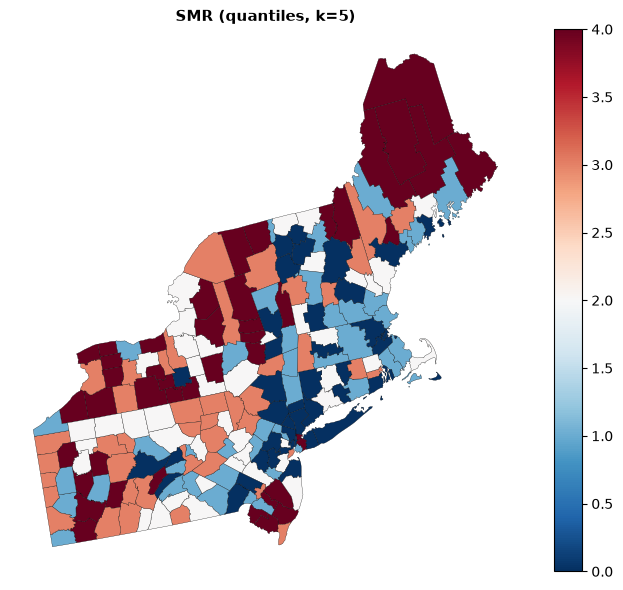

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
choropleth(counties.assign(SMR=raw), "SMR", scheme="quantiles", k=5, ax=ax, cmap="RdBu_r")
plt.tight_layout()
plt.show()

***
## 6. A Data Surprise: SMR and the Reported Prevalence Disagree

A natural expectation: since $E$ is just population scaled by a constant reference rate, $SMR = O/E$ should be
almost exactly proportional to the reported `Dia_pct` (both are, after all, "diabetes cases relative to
population"). Checking this directly:

In [5]:
implied_pct = O / POP * 100   # what Dia_pct "should" be if Dia_count and POP_Total were self-consistent
reported_pct = counties["Dia_pct"].to_numpy()

corr = np.corrcoef(implied_pct, reported_pct)[0, 1]
print(f"correlation(Dia_count/POP_Total*100, reported Dia_pct): {corr:.3f}  (not 1.0!)")
print(f"correlation(SMR, reported Dia_pct)                    : {np.corrcoef(raw, reported_pct)[0, 1]:.3f}")
diff = np.abs(implied_pct - reported_pct)
print(f"|implied - reported| pct-point difference: mean={diff.mean():.3f}, max={diff.max():.3f}")

correlation(Dia_count/POP_Total*100, reported Dia_pct): 0.801  (not 1.0!)
correlation(SMR, reported Dia_pct)                    : 0.801
|implied - reported| pct-point difference: mean=0.709, max=3.152


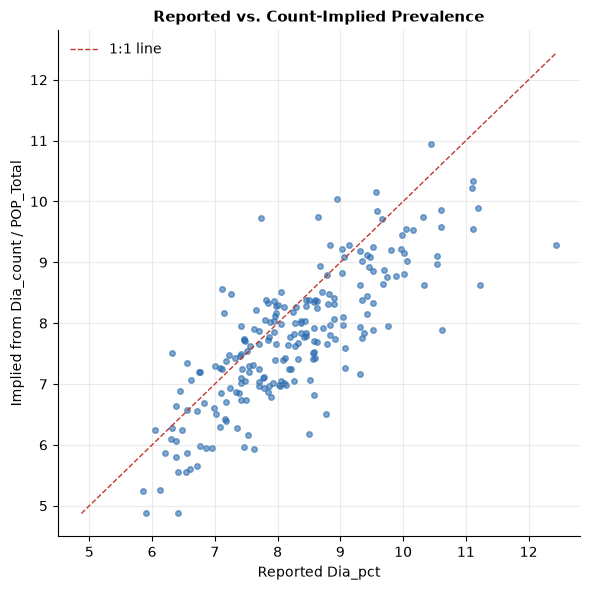

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(reported_pct, implied_pct, s=16, color=C["blue"], alpha=0.6)
lims = [min(reported_pct.min(), implied_pct.min()), max(reported_pct.max(), implied_pct.max())]
ax.plot(lims, lims, color=C["red"], lw=1, ls="--", label="1:1 line")
ax.set_xlabel("Reported Dia_pct")
ax.set_ylabel("Implied from Dia_count / POP_Total")
ax.legend()
ax.set_title("Reported vs. Count-Implied Prevalence")
plt.tight_layout()
plt.show()

**Only a 0.80 correlation, not 1.0** — `Dia_count`/`POP_Total` and `Dia_pct` are **not** mutually consistent
fields in this dataset. The most likely explanation, consistent with how CDC-style small-area health datasets
are typically assembled: `Dia_pct` is a **model-based estimate** (from a survey, potentially age-adjusted or
borrowing strength across areas already), while `Dia_count` and `POP_Total` are separate administrative fields
not derived from `Dia_pct` by simple multiplication. This is exactly the kind of cross-field inconsistency
worth checking *before* trusting a derived quantity — every SMR, confidence interval, and smoothed estimate in
this Part is built from `Dia_count`/`POP_Total`, and should be understood as a distinct, internally consistent
quantity from `Dia_pct`, not a recomputation of it. Both are legitimate to analyse; they are just not the same
number.

***
## 7. How Much of the Autocorrelation Is Population-Driven?

With that caveat in hand, compare Moran's I of the SMR (built from counts and population) against Moran's I of
the reported `Dia_pct` used throughout Parts 2–4.

In [7]:
moran_smr = Moran(raw, w_row, permutations=999, seed=1)
moran_pct = Moran(reported_pct, w_row, permutations=999, seed=1)
print(f"Moran's I, SMR (O/E)     : {moran_smr.I:.4f}  (p_sim={moran_smr['p_sim']:.4f})")
print(f"Moran's I, reported Dia_pct : {moran_pct.I:.4f}  (p_sim={moran_pct['p_sim']:.4f})")

Moran's I, SMR (O/E)     : 0.3299  (p_sim=0.0010)
Moran's I, reported Dia_pct : 0.2398  (p_sim=0.0010)


The SMR's autocorrelation (0.330) is actually **higher** than the reported prevalence's (0.240) — the opposite
of what a naive "unequal populations inflate apparent clustering" story would predict. Given Section 6's
finding, this is not surprising: the two variables are measuring genuinely different (if correlated) things,
and the SMR's derivation from raw administrative counts may carry a different, possibly stronger, spatial
signal than the modelled `Dia_pct` estimate. The lesson generalises beyond this specific pair of columns:
**always verify what a variable's autocorrelation is telling you about *before* attributing a change in Moran's
I to a specific mechanism** (like population weighting) — here the real explanation is a data-consistency issue
uncovered only by checking, not the mechanism a first guess would suggest.

***
## 8. Summary and Conclusions

This chapter built the complete raw baseline that every smoothing method in Chapters 5.5–5.8 is judged against.

### What we did

1. Computed the SMR and confirmed the smallest counties have the widest exact confidence intervals, as
   Chapter 5.2's theory predicts.
2. Ran `smr_confidence_interval` and `excess_pvalue`: 189 of 217 counties (87%) show a significant excess or
   deficit at the 95% level — a striking number, matching Chapter 5.2's funnel-plot overdispersion finding.
3. Mapped the raw SMR — the reference map for every later comparison.
4. **Found and investigated a real data inconsistency**: `Dia_count`/`POP_Total` does not reproduce the
   reported `Dia_pct` (correlation 0.80, not 1.0), most likely because `Dia_pct` is a separately modelled
   estimate rather than a direct count-over-population computation.
5. Compared Moran's I of the SMR (0.330) against the reported rate (0.240), and traced the difference to
   Section 6's data-consistency finding rather than a population-weighting mechanism.

### Practical takeaways

- Never assume two related-sounding columns in a real dataset are numerically consistent — check directly, as
  Section 6 did, before building an analysis on the assumption that they are.
- A striking share of "significant" counties under naive Poisson intervals (87% here) does not mean the data is
  full of real excess risk — it is a symptom of overdispersion that empirical Bayes and BYM are specifically
  built to separate from genuine signal (Chapters 5.5–5.6).
- When an autocorrelation number surprises you, investigate the data before attributing it to a plausible-
  sounding mechanism.

### Next steps

**Chapter 5.5 (Empirical Bayes Smoothing)** takes this chapter's raw SMR and applies the first family of
remedies: gamma–Poisson, normal/James–Stein, and spatial local empirical Bayes.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Lawson, A. B. (2018). *Bayesian Disease Mapping* (3rd ed.). CRC Press. | The SMR and its exact interval, Chapter 2 |
| Garwood, F. (1936). Fiducial limits for the Poisson distribution. *Biometrika*, 28, 437–442. | Origin of the exact Poisson interval used by `smr_confidence_interval` |

### Key papers

| Paper | Contribution |
|---|---|
| Breslow, N. E. & Day, N. E. (1987). *Statistical Methods in Cancer Research, Vol. II: The Design and Analysis of Cohort Studies*. IARC. | Standard reference on SMR construction and standardisation |

### In this library

| Object | Role |
|---|---|
| `spatialstats.bayes.smr`, `smr_confidence_interval`, `excess_pvalue` | Every raw quantity computed in this chapter |
| `spatialstats.viz.choropleth` | The SMR reference map |
| `spatialstats.esda.Moran` | Reused from Part 2 for Section 7's comparison |
| Chapter 5.5 | The first smoothing remedy applied to this chapter's raw SMR |